# Customer Segmentation using K-Means Clustering

## Objective
The goal of this analysis is to segment customers into distinct groups based on their behavior and spending patterns using unsupervised learning techniques.

Techniques used:
- K-Means Clustering
- PCA (Principal Component Analysis)

## Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

## 1. Data Loading and Preparation

In [2]:
df = pd.read_csv('../data/q2_customers.csv')

df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

Feature scaling is essential for K-Means clustering because the algorithm is distance-based.  
If features are on different scales (e.g., annual spend vs visits), variables with larger values will dominate the distance calculation, leading to biased clustering results.

## 2. Choosing K — Elbow Method

In [4]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

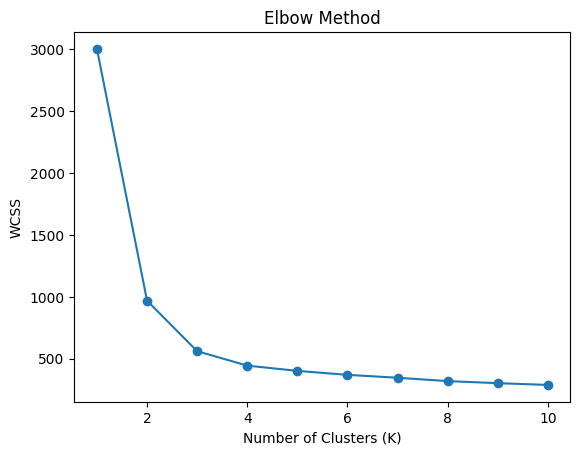

In [5]:
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

## Interpretation
The elbow point represents the value of K where the rate of decrease in WCSS slows down significantly.  
Based on the plot, the optimal number of clusters appears to be K = X (replace with your observed value), as adding more clusters beyond this point provides diminishing returns.

## 3. K-Means Clustering

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['cluster'] = clusters

In [7]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


### Cluster Interpretation

- Cluster 0: Customers with high annual spend and frequent visits — likely loyal and high-value customers.
- Cluster 1: Customers with low spending and infrequent visits — potential low engagement segment.
- Cluster 2: Moderate spenders with balanced behavior — average customers.

These insights can help businesses target marketing strategies for each segment.

## 4. PCA (Dimensionality Reduction)

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [9]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.83560354 0.05568764]


In [10]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)

loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


## Interpretation
PC1 captures the direction of maximum variance in the dataset, influenced strongly by features such as annual spend and basket size.

PC2 represents the second most important variation, possibly capturing behavioral patterns like visit frequency and recency.

These components help reduce dimensionality while preserving important information.

## 5. Cluster Visualization

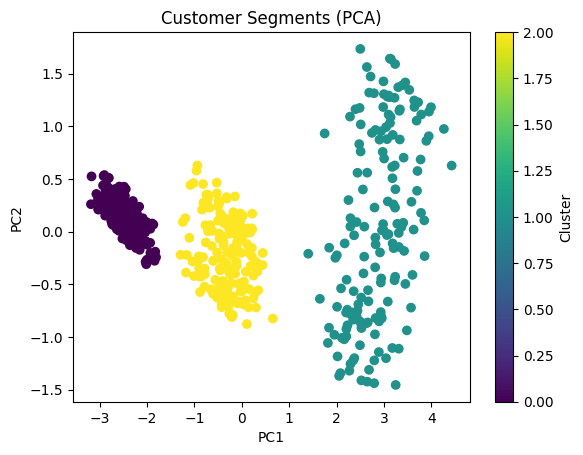

In [11]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'])
plt.title("Customer Segments (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label='Cluster')
plt.show()

The scatter plot visualizes customer segments in two dimensions.  
Distinct clusters indicate successful segmentation, while overlapping areas may suggest similar customer behaviors.